In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# --- Ingående Kod ---
iris = load_iris()
X, y = load_iris(return_X_y=True, as_frame=True)
X = X[['sepal length (cm)', 'sepal width (cm)']]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)
classes = ['setosa', 'versicolor', 'virginica']

In [3]:
# ---  ML-flödet ---

# 1. Skala datan
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 2. Instantiera och träna en baslinjemodell
log_clf = LogisticRegression(random_state=42)
log_clf.fit(X_train_scaled, y_train)

# 3. Prediktera och utvärdera på valideringsdatan
y_val_pred = log_clf.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validering Accuracy: {val_accuracy:.2f}")
print("\nClassification Report (Validering):")
print(classification_report(y_val, y_val_pred, target_names=classes))


Validering Accuracy: 0.72

Classification Report (Validering):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.56      0.75      0.64        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.72        36
   macro avg       0.75      0.75      0.74        36
weighted avg       0.74      0.72      0.72        36



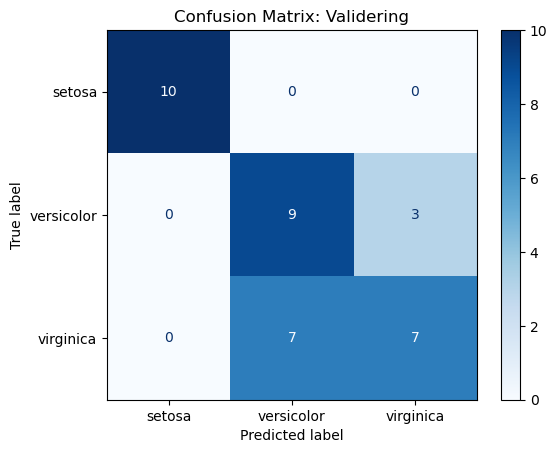

In [4]:
# Visualisera Confusion Matrix för valideringsdatan
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Validering")
plt.show()

In [5]:
# 4. Träna om modellen på all träningsdata (Train + Validation)
#  skalning om den sammanslagna datan
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_scaled = scaler_full.transform(X_test)

log_clf_final = LogisticRegression(random_state=42)
log_clf_final.fit(X_train_full_scaled, y_train_full)

# 5. Sista utvärdering på testdatan
y_test_pred = log_clf_final.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nSlutgiltig Test Accuracy: {test_accuracy:.2f}")


Slutgiltig Test Accuracy: 0.93


Denna ML-modell har gissat rätt i 93 procent av fallen när den prövades på helt ny data som den aldrig har sett tidigare. Om den till exempel fick titta på 100 nya exempel, klassificerade den 93 av dem helt korrekt och gjorde fel på endast 7 stycken. Till slut modellen med säkerhet faktiskt förstår de underliggande mönstren och är redo att användas i verkligheten.